<center><img src="redpopcorn.jpg"></center>

# Netflix 1990s Movie EDA

This notebook performs exploratory data analysis on `netflix_data.csv` to answer two required questions about movies released in the 1990s.

## Objectives
1. Identify the most frequent movie duration in the 1990s and store it in `duration` (integer).
2. Count short action movies (`duration < 90`) released in the 1990s and store the result in `short_movie_count` (integer).

## Dataset
### `netflix_data.csv`
| Column         | Description                          |
|----------------|--------------------------------------|
| `show_id`      | Unique show identifier               |
| `type`         | Content type                         |
| `title`        | Title                                |
| `director`     | Director                             |
| `cast`         | Cast                                 |
| `country`      | Country of origin                    |
| `date_added`   | Date added to Netflix                |
| `release_year` | Release year                         |
| `duration`     | Duration in minutes                  |
| `description`  | Description                          |
| `genre`        | Genre                                |

## 1. Environment Setup

In [ ]:
# Load analysis dependencies
import pandas as pd
import matplotlib.pyplot as plt

# Load Netflix dataset into a DataFrame
netflix_df = pd.read_csv("netflix_data.csv")

## 2. Data Quality Snapshot

Perform a quick validation of structure, completeness, and numeric distributions before filtering.

In [12]:
# Preview sample records
netflix_df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
1,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
2,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action


In [13]:
# Summarize shape, schema, and missing values
print(f"Rows: {netflix_df.shape[0]}, Columns: {netflix_df.shape[1]}")
display(netflix_df.dtypes.to_frame("dtype").T)
netflix_df.isna().sum().sort_values(ascending=False).head(5)

Rows: 4812, Columns: 11


,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
dtype,str,str,str,str,str,str,str,int64,int64,str,str


show_id     0
type        0
title       0
director    0
cast        0
dtype: int64

In [14]:
# Review descriptive statistics for key numeric fields
netflix_df[["release_year", "duration"]].describe()

,release_year,duration
count,4812.000000,4812.000000
mean,2012.711554,99.566708
std,9.517978,30.889305
min,1942.000000,1.000000
25%,2011.000000,88.000000
50%,2016.000000,99.000000
75%,2018.000000,116.000000
max,2021.000000,253.000000


## 3. Filter Scope: 1990s Movies

Restrict analysis to records where `type == "Movie"` and `release_year` is between 1990 and 1999 (inclusive).

In [15]:
# Keep only movie records
movies = netflix_df[netflix_df["type"] == "Movie"]
movies.shape

(4677, 11)

In [16]:
# Filter movies released in the 1990s (1990-1999 inclusive)
movies_90s = movies[(movies["release_year"] >= 1990) &
                   (movies["release_year"] <= 1999)]

print(f"1990s movie count: {movies_90s.shape[0]}")
print(f"Year range: {movies_90s['release_year'].min()}-{movies_90s['release_year'].max()}")

1990s movie count: 183
Year range: 1990-1999


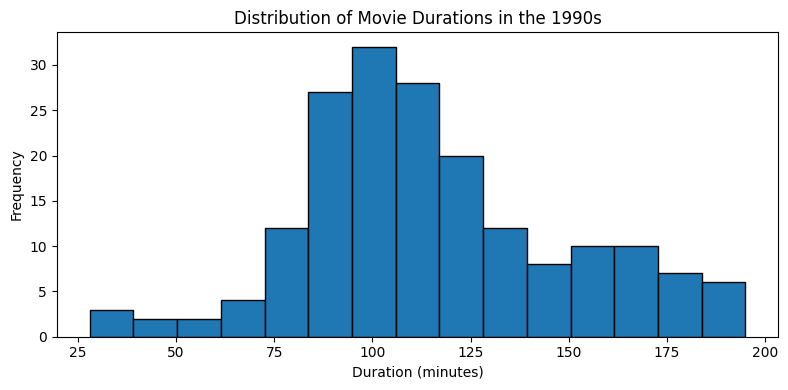

In [17]:
# Visualize duration distribution for 1990s movies
plt.figure(figsize=(8, 4))
plt.hist(movies_90s["duration"], bins=15, edgecolor="black")
plt.title("Distribution of Movie Durations in the 1990s")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 4. Duration Insight

The distribution centers near 90-110 minutes. The exact required answer is computed with the mode in the next step.

In [18]:
# Compute the most frequent duration (mode)
duration = int(movies_90s["duration"].mode()[0])
duration

94

In [22]:
# Keep only action movies released in the 1990s
action_movies_1990s = movies_90s[movies_90s["genre"] == "Action"]
action_movies_1990s.shape

(48, 11)

In [23]:
# Count short action movies (duration < 90 minutes) using an explicit loop
short_movie_count = 0

for _, row in action_movies_1990s.iterrows():
    if row["duration"] < 90:
        short_movie_count = short_movie_count + 1

short_movie_count

7

## 5. Final Answers

The required output variables are reported below for submission.

In [21]:
# Submission variables
print(f"duration = {duration}")
print(f"short_movie_count = {short_movie_count}")

duration = 94
short_movie_count = 7
